In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization, Activation
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.utils import class_weight

# Check for GPU
print("TensorFlow Version:", tf.__version__)
if tf.config.list_physical_devices('GPU'):
    print("GPU is available! Training will be fast.")
else:
    print("GPU is NOT available. Training might be slow on CPU.")

TensorFlow Version: 2.19.0
GPU is available! Training will be fast.


In [ ]:
# Install Kaggle library
!pip install -q kaggle

# Upload kaggle.json
from google.colab import files
if not os.path.exists('kaggle.json'):
    print("Please upload your kaggle.json file:")
    files.upload()

# Move kaggle.json to the correct directory
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# Download the dataset
if not os.path.exists('fer2013.zip'):
    print("Downloading dataset...")
    !kaggle datasets download -d msambare/fer2013

# Unzip the dataset
if not os.path.exists('train'):
    print("Unzipping dataset...")
    !unzip -q fer2013.zip -d .
    print("Dataset downloaded and extracted successfully!")
else:
    print("Dataset already exists.")

Dataset already exists.


In [ ]:
# Define paths to your dataset
train_dir = './train'
test_dir = './test'

print(f"Training Directory: {train_dir}")
print(f"Testing Directory: {test_dir}")

Training Directory: ./train
Testing Directory: ./test


Training Set Distribution: {'sad': 4830, 'disgust': 436, 'surprise': 3171, 'neutral': 4965, 'angry': 3995, 'fear': 4097, 'happy': 7215}
Test Set Distribution: {'sad': 1247, 'disgust': 111, 'surprise': 831, 'neutral': 1233, 'angry': 958, 'fear': 1024, 'happy': 1774}


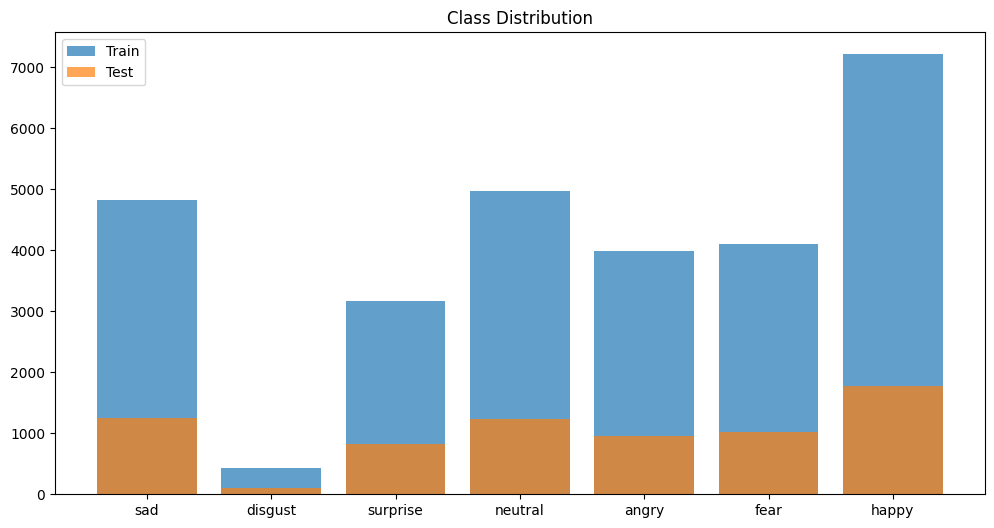

In [ ]:
def count_images(directory):
    counts = {}
    if not os.path.exists(directory):
        print(f"Directory not found: {directory}")
        return counts

    for emotion in os.listdir(directory):
        path = os.path.join(directory, emotion)
        if os.path.isdir(path):
            counts[emotion] = len(os.listdir(path))
    return counts

train_counts = count_images(train_dir)
test_counts = count_images(test_dir)

print("Training Set Distribution:", train_counts)
print("Test Set Distribution:", test_counts)

# Plot distribution
plt.figure(figsize=(12, 6))
plt.bar(train_counts.keys(), train_counts.values(), label='Train', alpha=0.7)
plt.bar(test_counts.keys(), test_counts.values(), label='Test', alpha=0.7)
plt.title('Class Distribution')
plt.legend()
plt.show()

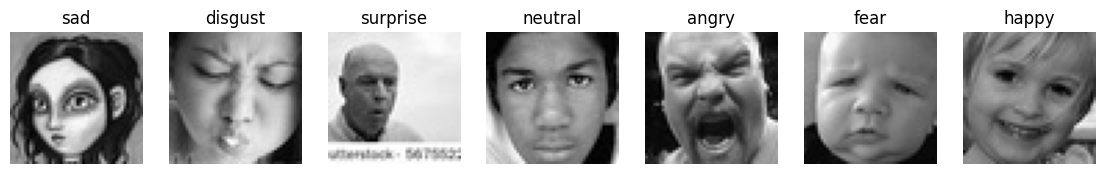

In [ ]:
# Display sample images
plt.figure(figsize=(14, 10))
emotions = os.listdir(train_dir)
i = 1
for emotion in emotions:
    path = os.path.join(train_dir, emotion)
    if os.path.isdir(path):
        img_file = os.listdir(path)[0] # Get first image
        img_path = os.path.join(path, img_file)
        img = plt.imread(img_path)

        plt.subplot(1, 7, i)
        plt.imshow(img, cmap='gray')
        plt.title(emotion)
        plt.axis('off')
        i += 1
plt.show()

In [ ]:
img_size = 96
batch_size = 64

# Data Augmentation for Training
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.15,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

# Only Rescaling for Validation/Test
test_datagen = ImageDataGenerator(rescale=1./255)

# Load Data
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    color_mode='rgb',
    class_mode='categorical',
    shuffle=True
)

validation_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    color_mode='rgb',
    class_mode='categorical',
    shuffle=False
)

# Calculate Class Weights to handle imbalance
class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_generator.classes),
    y=train_generator.classes
)
class_weights_dict = dict(enumerate(class_weights))
print("Class Weights:", class_weights_dict)

Found 28709 images belonging to 7 classes.
Found 7178 images belonging to 7 classes.
Class Weights: {0: np.float64(1.0266046844269623), 1: np.float64(9.406618610747051), 2: np.float64(1.0010460615781582), 3: np.float64(0.5684387684387684), 4: np.float64(0.8260394187886635), 5: np.float64(0.8491274770777877), 6: np.float64(1.293372978330405)}


In [ ]:
from tensorflow.keras import regularizers
from tensorflow.keras.layers import GlobalAveragePooling2D

weight_decay = 5e-5  # slightly smaller L2 regularization

model = Sequential()

# Block 1
model.add(Conv2D(
    64, (3, 3), padding='same',
    kernel_regularizer=regularizers.l2(weight_decay),
    input_shape=(img_size, img_size, 3 )   # CHANGED: use img_size instead of (48, 48, 1)
))
model.add(BatchNormalization())
model.add(Activation('relu'))
model.add(Conv2D(64, (3, 3), padding='same',
                 kernel_regularizer=regularizers.l2(weight_decay)))
model.add(BatchNormalization())
model.add(Activation('relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.25))

# Block 2
model.add(Conv2D(128, (3, 3), padding='same',
                 kernel_regularizer=regularizers.l2(weight_decay)))
model.add(BatchNormalization())
model.add(Activation('relu'))
model.add(Conv2D(128, (3, 3), padding='same',
                 kernel_regularizer=regularizers.l2(weight_decay)))
model.add(BatchNormalization())
model.add(Activation('relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.30))

# Block 3
model.add(Conv2D(256, (3, 3), padding='same',
                 kernel_regularizer=regularizers.l2(weight_decay)))
model.add(BatchNormalization())
model.add(Activation('relu'))
model.add(Conv2D(256, (3, 3), padding='same',
                 kernel_regularizer=regularizers.l2(weight_decay)))
model.add(BatchNormalization())
model.add(Activation('relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.40))

# Global pooling instead of big Flatten + 2×512 dense
model.add(GlobalAveragePooling2D())

model.add(Dense(256, kernel_regularizer=regularizers.l2(weight_decay)))
model.add(BatchNormalization())
model.add(Activation('relu'))
model.add(Dropout(0.5))

# Output Layer
model.add(Dense(7, activation='softmax'))

# Loss with label smoothing
loss_fn = tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1)

# Compile Model
model.compile(
    optimizer=Adam(learning_rate=1e-3),  # CHANGED LR
    loss=loss_fn,
    metrics=['accuracy']
)

model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_12 (Conv2D)              │ (None, 96, 96, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 96, 96, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_14 (Activation)      │ (None, 96, 96, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 96, 96, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_15          │ (None, 96, 96, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_15 (Activation)      │ (None, 96, 96, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 48, 48, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 48, 48, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 48, 48, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_16          │ (None, 48, 48, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_16 (Activation)      │ (None, 48, 48, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 48, 48, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_17          │ (None, 48, 48, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_17 (Activation)      │ (None, 48, 48, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 24, 24, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 24, 24, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 24, 24, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_18          │ (None, 24, 24, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_18 (Activation)      │ (None, 24, 24, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 24, 24, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_19          │ (None, 24, 24, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_19 (Activation)      │ (None, 24, 24, 256)    │             

 Total params: 1,217,607 (4.64 MB)

 Trainable params: 1,215,303 (4.64 MB)

 Non-trainable params: 2,304 (9.00 KB)

In [ ]:
epochs = 40   # EarlyStopping will stop before 40 if no improvement

checkpoint = ModelCheckpoint(
    "model_weights.keras",
    monitor='val_accuracy',
    save_best_only=True,
    mode='max',
    verbose=1
)

early_stopping = EarlyStopping(
    monitor='val_accuracy',   # CHANGED
    patience=8,
    mode='max',
    verbose=1,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    verbose=1,
    min_lr=1e-6
)

callbacks = [checkpoint, early_stopping, reduce_lr]

history = model.fit(
    train_generator,
    epochs=epochs,
    validation_data=validation_generator,
    callbacks=callbacks,
    class_weight=class_weights_dict
)


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/40
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 256ms/step - accuracy: 0.1595 - loss: 2.3198
Epoch 1: val_accuracy improved from -inf to 0.14210, saving model to model_weights.keras
449/449 ━━━━━━━━━━━━━━━━━━━━ 146s 274ms/step - accuracy: 0.1595 - loss: 2.3195 - val_accuracy: 0.1421 - val_loss: 2.0202 - learning_rate: 0.0010
Epoch 2/40
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 224ms/step - accuracy: 0.1558 - loss: 2.0865
Epoch 2: val_accuracy did not improve from 0.14210
449/449 ━━━━━━━━━━━━━━━━━━━━ 105s 233ms/step - accuracy: 0.1558 - loss: 2.0864 - val_accuracy: 0.1232 - val_loss: 3.5343 - learning_rate: 0.0010
Epoch 3/40
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 221ms/step - accuracy: 0.1693 - loss: 2.0152
Epoch 3: val_accuracy improved from 0.14210 to 0.20619, saving model to model_weights.keras
449/449 ━━━━━━━━━━━━━━━━━━━━ 104s 231ms/step - accuracy: 0.1693 - loss: 2.0151 - val_accuracy: 0.2062 - val_loss: 1.9385 - learning_rate: 0.0010
Epoch 4/40
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 222ms/step - accuracy: 0.1

In [ ]:
# Plot Accuracy and Loss
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss')
plt.legend()

plt.show()

In [ ]:
# Confusion Matrix and Classification Report
validation_generator.reset()
predictions = model.predict(validation_generator)
y_pred = np.argmax(predictions, axis=1)
y_true = validation_generator.classes

class_labels = list(validation_generator.class_indices.keys())

print("Classification Report:\n")
print(classification_report(y_true, y_pred, target_names=class_labels))

plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

In [ ]:
import random

def predict_random_image():
    # Pick a random emotion folder
    emotion = random.choice(os.listdir(test_dir))
    emotion_path = os.path.join(test_dir, emotion)

    # Pick a random image
    img_file = random.choice(os.listdir(emotion_path))
    img_path = os.path.join(emotion_path, img_file)

    # Load and preprocess
    img = tf.keras.preprocessing.image.load_img(img_path, target_size=(48, 48), color_mode='grayscale')
    img_array = tf.keras.preprocessing.image.img_to_array(img)
    img_array = img_array / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    # Predict
    prediction = model.predict(img_array)
    predicted_label = class_labels[np.argmax(prediction)]

    # Display
    plt.imshow(img, cmap='gray')
    plt.title(f"True: {emotion} | Pred: {predicted_label}")
    plt.axis('off')
    plt.show()

# Show 3 predictions
for _ in range(3):
    predict_random_image()